In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from timm import create_model  # For GhostNet
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import os
import time
import itertools
from tqdm import tqdm
import torch.multiprocessing as mp

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# Constants
IMAGE_SIZE = 224  # GhostNet uses 224x224
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50
NUM_CLASSES = 8
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'

In [10]:
# Data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(5),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.9, 1.0)),
        transforms.ColorJitter(brightness=0.05, contrast=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [11]:
# Load dataset
dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['train'])
class_names = dataset.classes

# Dataset splitting
def dataset_split(dataset, train_split=0.75, val_split=0.15, test_split=0.15):
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    np.random.seed(12)
    np.random.shuffle(indices)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4, pin_memory=True)
    val_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4, pin_memory=True)
    test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler, num_workers=4, pin_memory=True)
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = dataset_split(dataset)

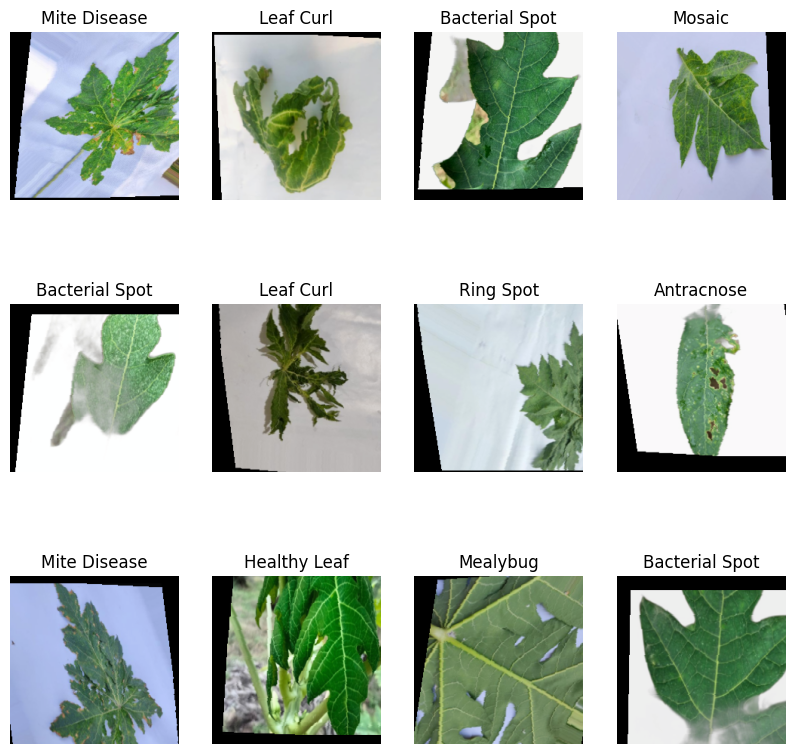

In [12]:
# Visualize some images
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10, 10))
for images, labels in train_loader:
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        imshow(images[i], class_names[labels[i]])
    break
plt.show()



In [13]:
# Model definition
model = create_model('ghostnet_100', pretrained=True, num_classes=NUM_CLASSES).to(device)
# Freeze base model
for param in model.parameters():
    param.requires_grad = False
# Unfreeze the classifier
for param in model.head.parameters():
    param.requires_grad = True

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.head.parameters(), lr=0.0001)
# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Progress bar for training
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch')
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Update progress bar
            train_pbar.set_postfix({
                'loss': running_loss / total,
                'accuracy': correct / total
            })
        
        train_loss = running_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / total
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        epoch_time = time.time() - start_time
        steps_per_epoch = len(train_loader)
        time_per_step = epoch_time / steps_per_epoch
        
        print(f"{steps_per_epoch}/{steps_per_epoch} ━━━━━━━━━━━━━━━━━━━━ {int(epoch_time)}s {int(time_per_step)}s/step - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")
        
        # Save model checkpoint
        torch.save(model.state_dict(), 'checkpoint.pt')
    
    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

AttributeError: 'GhostNet' object has no attribute 'head'

In [15]:
!pip install timm tqdm


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


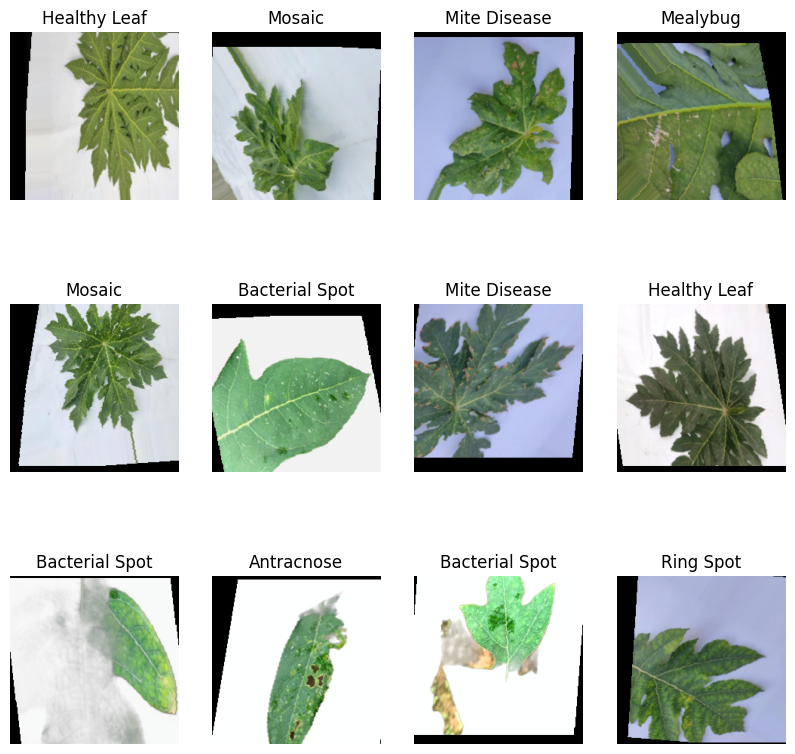

Epoch 1/50: 100%|██████████| 219/219 [01:03<00:00,  3.44batch/s, loss=1.83, accuracy=0.475]


219/219 ━━━━━━━━━━━━━━━━━━━━ 77s 0s/step - accuracy: 0.4754 - loss: 1.8302 - val_accuracy: 0.7330 - val_loss: 1.5662


Epoch 2/50: 100%|██████████| 219/219 [01:02<00:00,  3.53batch/s, loss=1.44, accuracy=0.74] 


219/219 ━━━━━━━━━━━━━━━━━━━━ 75s 0s/step - accuracy: 0.7395 - loss: 1.4396 - val_accuracy: 0.8116 - val_loss: 1.2445


Epoch 3/50: 100%|██████████| 219/219 [01:01<00:00,  3.54batch/s, loss=1.18, accuracy=0.789]


...

219/219 ━━━━━━━━━━━━━━━━━━━━ 77s 0s/step - accuracy: 0.9348 - loss: 0.2414 - val_accuracy: 0.9458 - val_loss: 0.2015


Epoch 49/50: 100%|██████████| 219/219 [01:03<00:00,  3.44batch/s, loss=0.232, accuracy=0.937]


219/219 ━━━━━━━━━━━━━━━━━━━━ 78s 0s/step - accuracy: 0.9373 - loss: 0.2323 - val_accuracy: 0.9643 - val_loss: 0.1782


Epoch 50/50: 100%|██████████| 219/219 [01:03<00:00,  3.46batch/s, loss=0.235, accuracy=0.938]


219/219 ━━━━━━━━━━━━━━━━━━━━ 77s 0s/step - accuracy: 0.9381 - loss: 0.2350 - val_accuracy: 0.9615 - val_loss: 0.1734


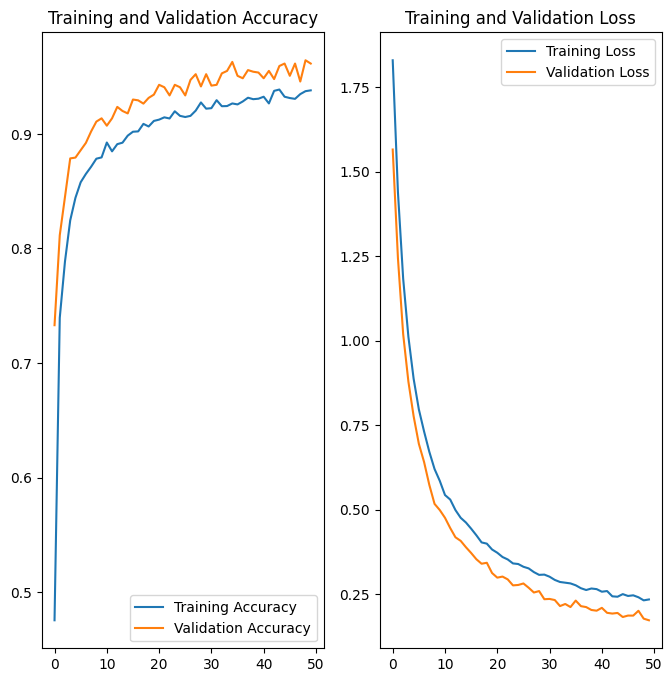

✅ Overall Accuracy: 0.9508
✅ Overall Precision: 0.9514
✅ Overall Recall: 0.9508
✅ Overall F1-Score: 0.9509
✅ Overall ROC AUC Score: 0.9980

Classification Report:
                precision    recall  f1-score   support

    Antracnose       0.92      0.93      0.92       131
Bacterial Spot       0.92      0.92      0.92       128
  Healthy Leaf       1.00      0.97      0.99       116
     Leaf Curl       0.96      0.92      0.94       141
      Mealybug       0.97      1.00      0.98        94
  Mite Disease       1.00      0.97      0.99       108
        Mosaic       0.91      0.94      0.93       105
     Ring Spot       0.94      0.96      0.95       112

      accuracy                           0.95       935
     macro avg       0.95      0.95      0.95       935
  weighted avg       0.95      0.95      0.95       935

Confusion matrix, without normalization


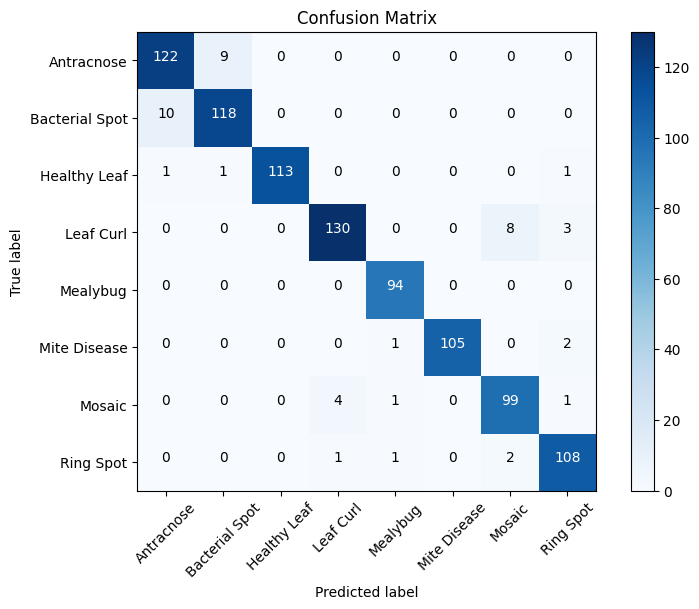

Normalized confusion matrix


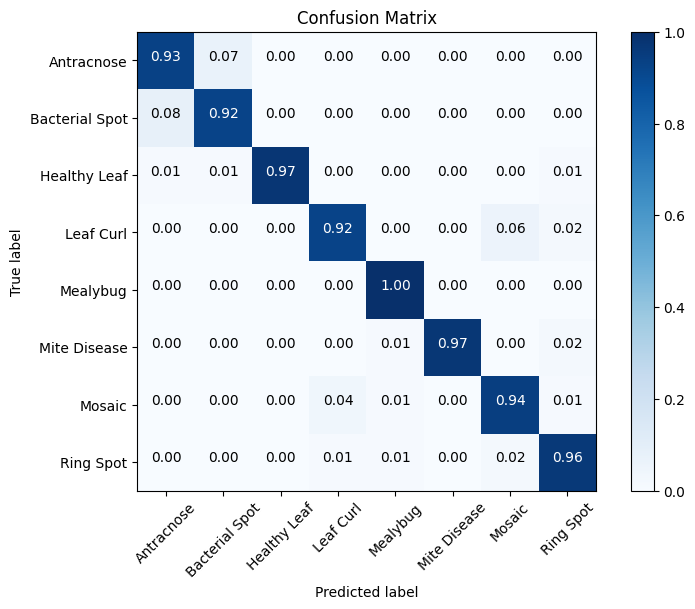

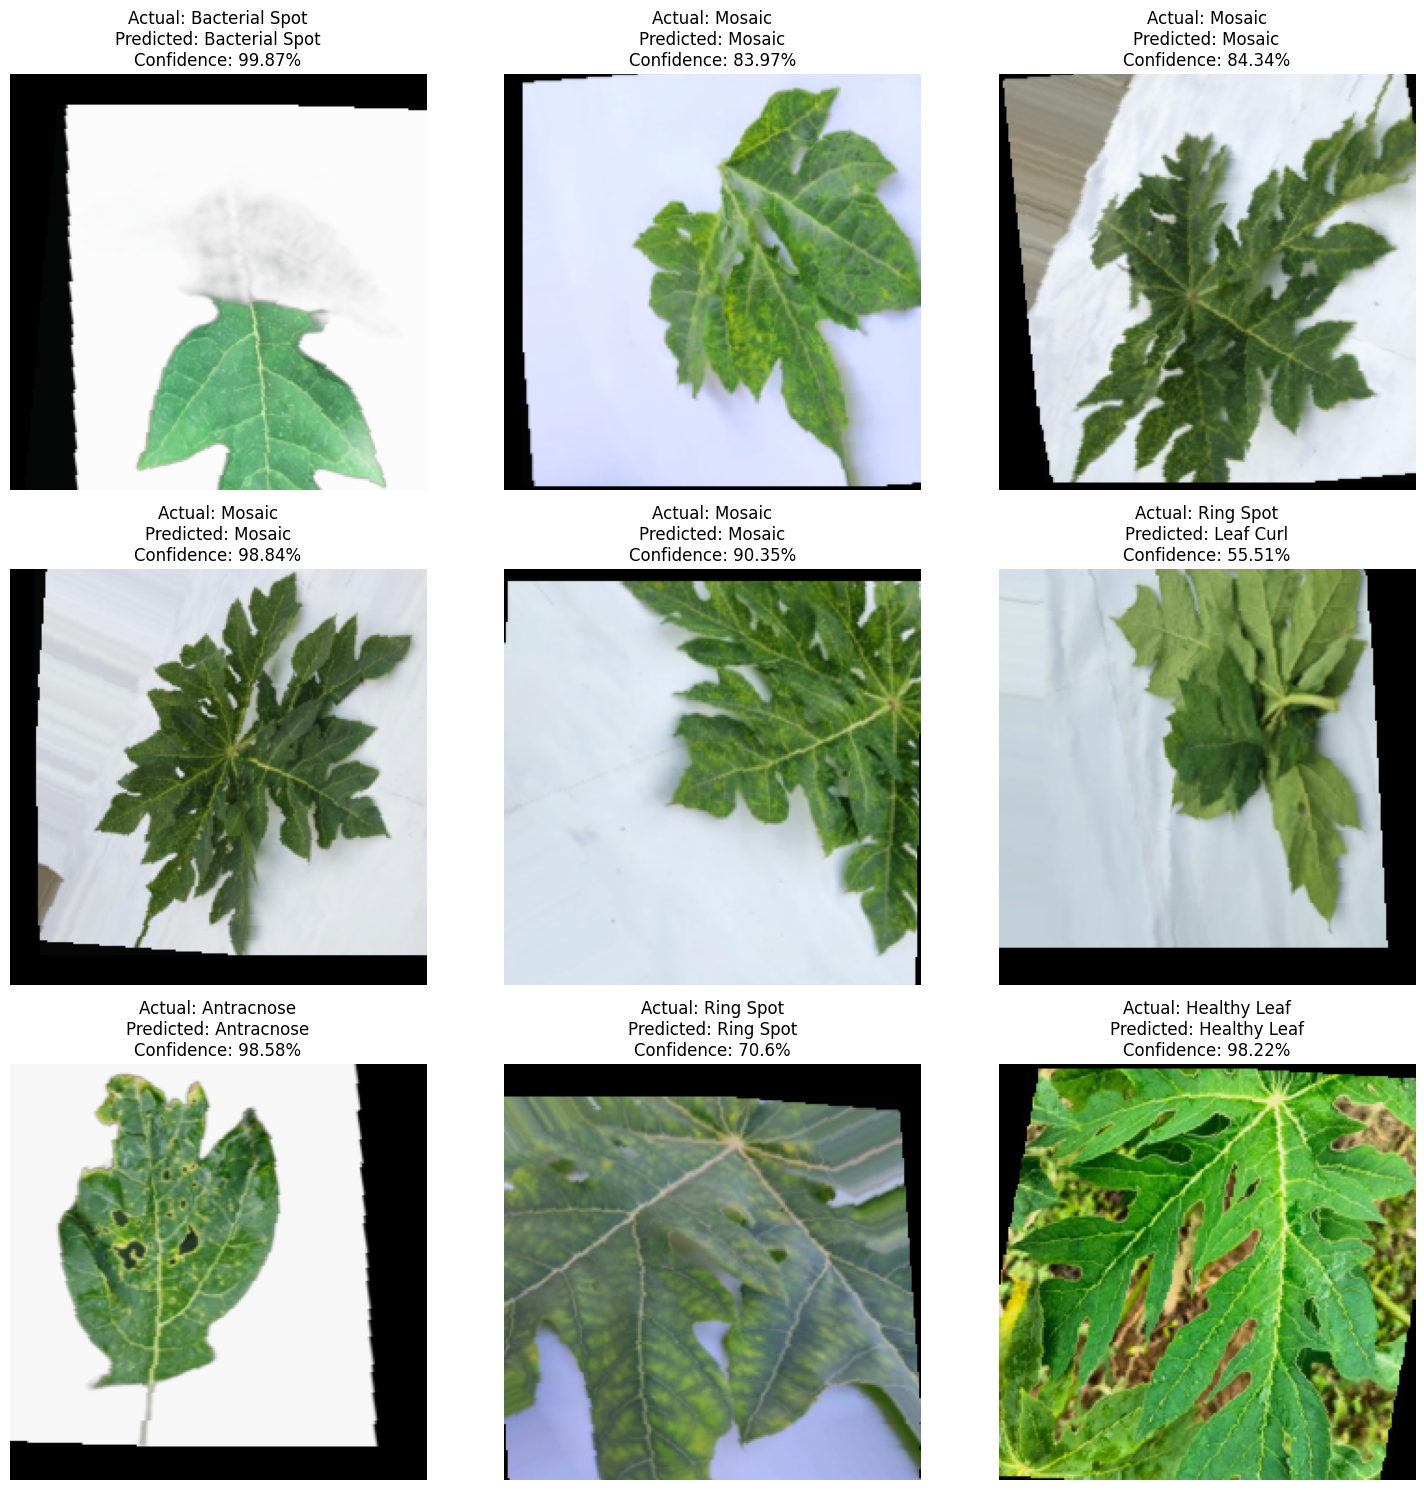

Model Size: 15.17 MB
Average Inference Time: 47.37 ms per image


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from timm import create_model  # For GhostNet
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import os
import time
import itertools
from tqdm import tqdm
import torch.multiprocessing as mp

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Constants
IMAGE_SIZE = 224  # GhostNet uses 224x224
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50
NUM_CLASSES = 8
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'

# Data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(5),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.9, 1.0)),
        transforms.ColorJitter(brightness=0.05, contrast=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Load dataset
dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['train'])
class_names = dataset.classes

# Dataset splitting
def dataset_split(dataset, train_split=0.75, val_split=0.15, test_split=0.15):
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    np.random.seed(12)
    np.random.shuffle(indices)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=2, pin_memory=True)
    test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler, num_workers=2, pin_memory=True)
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = dataset_split(dataset)

# Visualize some images
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10, 10))
for images, labels in train_loader:
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        imshow(images[i], class_names[labels[i]])
    break
plt.show()

# Model definition
model = create_model('ghostnet_100', pretrained=True, num_classes=NUM_CLASSES).to(device)

# Freeze base model
for param in model.parameters():
    param.requires_grad = False
# Unfreeze the classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)

# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Progress bar for training
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch')
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Update progress bar
            train_pbar.set_postfix({
                'loss': running_loss / total,
                'accuracy': correct / total
            })
        
        train_loss = running_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / total
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        epoch_time = time.time() - start_time
        steps_per_epoch = len(train_loader)
        time_per_step = epoch_time / steps_per_epoch
        
        print(f"{steps_per_epoch}/{steps_per_epoch} ━━━━━━━━━━━━━━━━━━━━ {int(epoch_time)}s {int(time_per_step)}s/step - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")
        
        # Save model checkpoint
        torch.save(model.state_dict(), '/kaggle/working/checkpoint.pt')
    
    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

# Plot training history
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Evaluation
def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    roc_auc = roc_auc_score(y_true_bin, y_probs, average='weighted', multi_class='ovr')
    
    print(f"✅ Overall Accuracy: {accuracy:.4f}")
    print(f"✅ Overall Precision: {precision:.4f}")
    print(f"✅ Overall Recall: {recall:.4f}")
    print(f"✅ Overall F1-Score: {f1:.4f}")
    print(f"✅ Overall ROC AUC Score: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix'):
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            print("Normalized confusion matrix")
        else:
            print('Confusion matrix, without normalization')
        
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)
        
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        
        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show()
    
    plot_confusion_matrix(cm, class_names)
    plot_confusion_matrix(cm, class_names, normalize=True)
    
    return y_true, y_pred, y_probs

y_true, y_pred, y_probs = evaluate_model(model, test_loader)

# Prediction function
def predict(model, image):
    model.eval()
    image = image.to(device)
    with torch.no_grad():
        output = model(image.unsqueeze(0))
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = round(probabilities[0][predicted_class].item() * 100, 2)
    return class_names[predicted_class], confidence

# Visualize predictions
plt.figure(figsize=(15, 15))
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[labels[i]]
        imshow(images[i].cpu(), f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
    break
plt.tight_layout()
plt.show()

# Model size and inference speed
def measure_model_size_and_speed(model):
    torch.save(model.state_dict(), '/kaggle/working/ghostnet.pt')
    model_size_mb = os.path.getsize('/kaggle/working/ghostnet.pt') / (1024 * 1024)
    print(f"Model Size: {model_size_mb:.2f} MB")
    
    model.eval()
    dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    times = []
    for _ in range(10):
        start_time = time.time()
        with torch.no_grad():
            _ = model(dummy_input)
        times.append((time.time() - start_time) * 1000)
    
    avg_inference_time = sum(times) / len(times)
    print(f"Average Inference Time: {avg_inference_time:.2f} ms per image")

measure_model_size_and_speed(model)